# Cross-Model Transfer: Does a Refusal Direction Found on One Model Do Anything on Another?

`mechanism.ipynb` asks why detection and causal robustness vary *within* a
model's own refusal mechanism. This notebook asks a different question:
does the actual direction found on one model do anything when applied to a
*different* model's activations or generation? Tested on two
architecture-matched pairs -- Qwen3-8B <-> Llama-3.1-8B-Instruct
(d_model=4096) and Qwen2.5-1.5B-Instruct <-> DeepSeek-R1-Distill-Qwen-1.5B
(d_model=1536) -- on both necessity (ablation) and sufficiency (activation
addition).

## Methods & formulas (reference)

**Separation score.** A direction's own separation score is the mean
projection gap between harmful and harmless VAL activations at its own
already-selected layer. Evaluating a *foreign* model's direction against a
target's own activations at the target's own layer asks whether that axis
separates anything at all in the target's representation space, independent
of whether it was ever meant to.

**Necessity vs. sufficiency.** Ablation (projecting the direction's
contribution out of every layer's residual stream) tests whether the
direction is *necessary* for refusal; activation addition (adding the raw
direction, scaled by a calibrated alpha) tests whether it is *sufficient* to
induce refusal. A direction can fail one test and pass the other, so both
are run rather than treating either as decisive alone.

**McNemar's exact test.** Paired binary refusal calls (same prompts, same
model, two conditions) are compared via the exact binomial test on the
discordant pairs -- see `mechanism.ipynb`'s reference section for the full
derivation.

**Stale-cache trap.** `results/cross_model_direction_transfer.json` stores
its Llama-3.1-8B conditions' `refusal_stats` from *before* a 2026-07-23
curly-apostrophe fix to `is_refusal` (see `reports/DECISIONS.md`); this
notebook reloads the raw `completions` and calls `is_refusal`/
`refusal_stats` fresh rather than trusting the stored fields, for that model
only -- Qwen3-8B's ASCII-apostrophe completions were never affected. The
second pair's DeepSeek-side conditions go the other way: their stored
`refusal_stats` already account for truncation-aware resolution
(`resolve_completions_by_index()`) that a naive rescore over raw
completions would get wrong, so those are trusted as-is.

### Setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from src.direction.refusal_classifier import is_refusal, refusal_stats
from src.eval.detector_metrics import mcnemar_exact

RESULTS = Path("..") / "results"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
    "axes.axisbelow": True,
    "figure.dpi": 130,
})

PALETTE = {
    "blue": "#2f5fd6",
    "vermilion": "#c0392b",
    "green": "#0d8f5c",
    "amber": "#c07a1e",
    "gray": "#8a8f98",
    "ink": "#1f2d3d",
}

## Part A -- Necessity: does ablating a foreign direction do anything? (Qwen3-8B <-> Llama-3.1-8B-Instruct)

### Separation score: foreign direction evaluated on the target's own held-out activations

In [2]:
with open(RESULTS / "cross_model_direction_transfer.json") as fh:
    xfer = json.load(fh)

sep = xfer["separation_score"]
SEP_ROWS = [
    ("Qwen3-8B", "Llama's direction", sep["llama_direction_on_qwen"]["own_score_at_own_layer"], sep["llama_direction_on_qwen"]["foreign_score_at_own_layer"]),
    ("Llama-3.1-8B", "Qwen3-8B's direction", sep["qwen_direction_on_llama"]["own_score_at_own_layer"], sep["qwen_direction_on_llama"]["foreign_score_at_own_layer"]),
]
SEP_ROWS

[('Qwen3-8B', "Llama's direction", 1.7830805778503418, -0.6454378366470337), ('Llama-3.1-8B', "Qwen3-8B's direction", 1.859663963317871, -0.7217569947242737)]

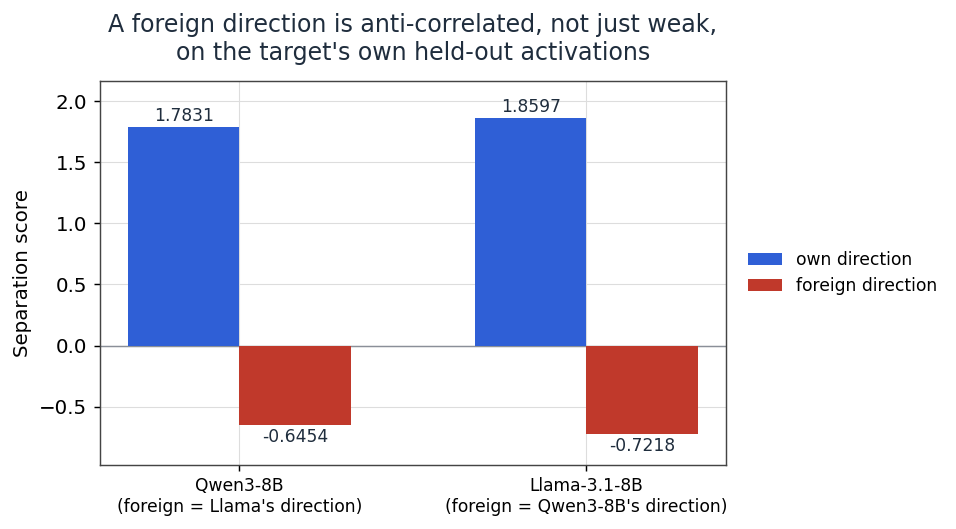

In [3]:
labels = [f"{model}\n(foreign = {foreign})" for model, foreign, _, _ in SEP_ROWS]
own_vals = [r[2] for r in SEP_ROWS]
foreign_vals = [r[3] for r in SEP_ROWS]

x = range(len(SEP_ROWS))
width = 0.32
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar([i - width / 2 for i in x], own_vals, width=width, label="own direction", color=PALETTE["blue"], zorder=3)
ax.bar([i + width / 2 for i in x], foreign_vals, width=width, label="foreign direction", color=PALETTE["vermilion"], zorder=3)
ax.axhline(0, color=PALETTE["gray"], linewidth=0.8, zorder=2)
ax.set_ylim(min(foreign_vals) - 0.25, max(own_vals) + 0.3)
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=9.5)
ax.set_ylabel("Separation score")
ax.set_title("A foreign direction is anti-correlated, not just weak,\non the target's own held-out activations", color=PALETTE["ink"], pad=12)
for i, v in enumerate(own_vals):
    ax.text(i - width / 2, v + 0.05, f"{v:.4f}", ha="center", fontsize=9.5, color=PALETTE["ink"])
for i, v in enumerate(foreign_vals):
    ax.text(i + width / 2, v - 0.14, f"{v:.4f}", ha="center", fontsize=9.5, color=PALETTE["ink"])
ax.legend(frameon=False, fontsize=9.5, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

### Causal ablation: baseline vs. own-ablation vs. foreign-ablation refusal rate

Llama-3.1-8B's conditions below are rescored fresh from raw completions
(see the stale-cache note above); Qwen3-8B's stored rates already match a
fresh rescore.

In [4]:
def rescore(conditions):
    return {c: refusal_stats(conditions[c]["completions"]) for c in ["baseline", "own_ablation", "foreign_ablation"]}

qwen_ablation = rescore(xfer["causal_ablation"]["llama_direction_on_qwen"]["conditions"])
llama_ablation = rescore(xfer["causal_ablation"]["qwen_direction_on_llama"]["conditions"])

def mcnemar_all(conditions):
    preds = {c: [is_refusal(x) for x in conditions[c]["completions"]] for c in ["baseline", "own_ablation", "foreign_ablation"]}
    return {
        "baseline_vs_own": mcnemar_exact(preds["baseline"], preds["own_ablation"]),
        "baseline_vs_foreign": mcnemar_exact(preds["baseline"], preds["foreign_ablation"]),
    }

qwen_mcnemar = mcnemar_all(xfer["causal_ablation"]["llama_direction_on_qwen"]["conditions"])
llama_mcnemar = mcnemar_all(xfer["causal_ablation"]["qwen_direction_on_llama"]["conditions"])
{"Qwen3-8B": {k: v["rate"] for k, v in qwen_ablation.items()}, "Llama-3.1-8B": {k: v["rate"] for k, v in llama_ablation.items()}}

{'Qwen3-8B': {'baseline': 0.84, 'own_ablation': 0.08, 'foreign_ablation': 0.84}, 'Llama-3.1-8B': {'baseline': 0.92, 'own_ablation': 0.88, 'foreign_ablation': 0.92}}

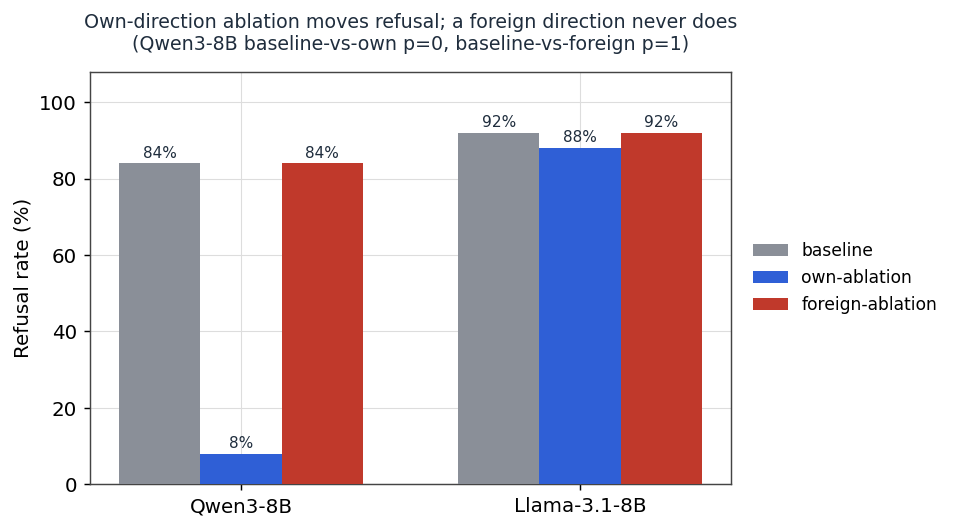

In [5]:
groups = ["Qwen3-8B", "Llama-3.1-8B"]
conds = ["baseline", "own_ablation", "foreign_ablation"]
cond_labels = ["baseline", "own-ablation", "foreign-ablation"]
cond_colors = [PALETTE["gray"], PALETTE["blue"], PALETTE["vermilion"]]
data = {"Qwen3-8B": qwen_ablation, "Llama-3.1-8B": llama_ablation}

x = range(len(groups))
width = 0.24
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for j, cond in enumerate(conds):
    vals = [data[g][cond]["rate"] * 100 for g in groups]
    offset = (j - 1) * width
    bars = ax.bar([i + offset for i in x], vals, width=width, color=cond_colors[j], label=cond_labels[j], zorder=3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f}%", ha="center", fontsize=8.5, color=PALETTE["ink"])
ax.set_ylim(0, 108)
ax.set_ylabel("Refusal rate (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(groups)
ax.set_title(
    "Own-direction ablation moves refusal; a foreign direction never does\n"
    f"(Qwen3-8B baseline-vs-own p={qwen_mcnemar['baseline_vs_own']['p_value']:.3g}, baseline-vs-foreign p={qwen_mcnemar['baseline_vs_foreign']['p_value']:.3g})",
    color=PALETTE["ink"], pad=12, fontsize=10.5,
)
ax.legend(frameon=False, fontsize=9.5, loc="center left", bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()

**Qwen3-8B: clean, unambiguous no-transfer.** Own-ablation crashes refusal
(84%->8%, baseline-vs-own p=0.0); Llama's foreign direction is
indistinguishable from baseline (84%->84%, p=1.0, 0 discordant pairs).

**Llama-3.1-8B: a real but small own-effect, and a foreign direction with
no effect.** Own-ablation shows a correctly-signed decrease (92%->88%) but
is not significant at n=50 (p=0.5, 2 discordant); Qwen3-8B's foreign
direction produces exactly zero change (92%->92%, p=1.0). An independent
n=75 replication of Llama's own-ablation effect
(`scripts/replicate_llama_ablation.py`) found an even smaller gap
(96.0%->94.7%, p=1.0) -- read honestly, this does not look like a real
small effect that needed more power, so Llama's dense direction's causal
necessity for its own refusal remains genuinely unresolved by this
project's data (contrast with SAE features, which do ablate it
dramatically -- see `mechanism.ipynb`).

## Part B -- Sufficiency: does adding a foreign direction induce refusal? (same pair)

Reuses each model's baseline/own-addition completions unchanged from Phase
1's 7-9B sufficiency sweep; only the foreign-direction alpha sweep needed
new generation, added at the target's own already-selected layer (same
convention as Part A).

In [6]:
with open(RESULTS / "sufficiency_transfer.json") as fh:
    suff = json.load(fh)

SUFF_GROUPS = ["Qwen3-8B", "Llama-3.1-8B-Instruct"]
suff_rates = {
    m: {
        "baseline": suff[m]["baseline"]["rate"] * 100,
        "own_addition": suff[m]["own_addition"]["rate"] * 100,
        "foreign_addition": suff[m]["foreign_addition"]["refusal_stats"]["rate"] * 100,
    }
    for m in SUFF_GROUPS
}
suff_rates

{'Qwen3-8B': {'baseline': 6.0, 'own_addition': 70.0, 'foreign_addition': 6.0}, 'Llama-3.1-8B-Instruct': {'baseline': 10.0, 'own_addition': 34.0, 'foreign_addition': 6.0}}

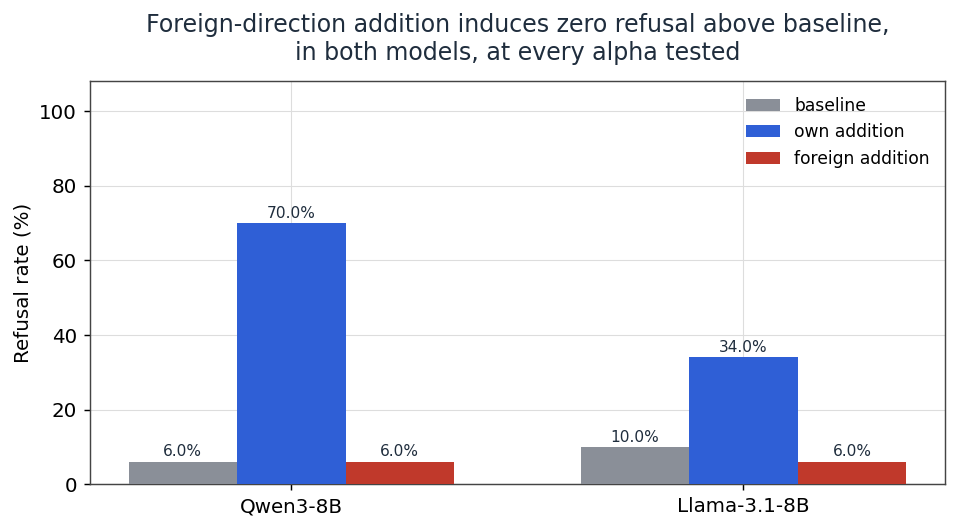

In [7]:
conds = ["baseline", "own_addition", "foreign_addition"]
cond_labels = ["baseline", "own addition", "foreign addition"]
cond_colors = [PALETTE["gray"], PALETTE["blue"], PALETTE["vermilion"]]
labels_short = ["Qwen3-8B", "Llama-3.1-8B"]

x = range(len(SUFF_GROUPS))
width = 0.24
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for j, cond in enumerate(conds):
    vals = [suff_rates[m][cond] for m in SUFF_GROUPS]
    offset = (j - 1) * width
    bars = ax.bar([i + offset for i in x], vals, width=width, color=cond_colors[j], label=cond_labels[j], zorder=3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=8.5, color=PALETTE["ink"])
ax.set_ylim(0, 108)
ax.set_ylabel("Refusal rate (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(labels_short)
ax.set_title("Foreign-direction addition induces zero refusal above baseline,\nin both models, at every alpha tested", color=PALETTE["ink"], pad=12)
ax.legend(frameon=False, fontsize=9.5, loc="upper right")
plt.tight_layout()
plt.show()

**A clean, symmetric null on the sufficiency side too.** Qwen3-8B: own
addition induces refusal in 70% of cases (6%->70%, baseline-vs-own
p<0.001); the foreign direction induces exactly 0 above baseline at every
alpha from 0.25 to 4.0 (p=1.0, 0/50 discordant). Llama-3.1-8B: own
addition's real 10%->34% effect is itself significant (p=0.0005) and
clearly distinct from the foreign direction's null effect (own-vs-foreign
p=0.0001) -- **this resolves what the necessity side left inconclusive**
for Llama (own-ablation vs. foreign-ablation couldn't be distinguished at
n=50; on the sufficiency side they clearly can). Zero degenerate
completions in either foreign-addition run, so the null isn't an artifact
of broken generation.

## Part C -- A second, architecture-matched pair: Qwen2.5-1.5B-Instruct <-> DeepSeek-R1-Distill-Qwen-1.5B

Both 1536-dimensional, found already sitting in this project's existing
six cached models. Necessity only -- sufficiency wasn't attempted this
round since DeepSeek's own-direction addition is already a
thoroughly-swept null elsewhere in this project. The design is asymmetric,
not a straight rerun of Part A's method: DeepSeek needs a 2048-token
whole-generation budget (vs. 40 tokens for every other model) and
`resolve_completions_by_index()` to keep McNemar's paired comparisons
correctly aligned once each condition truncates a different subset of
prompts -- so this section trusts the project's own precomputed,
truncation-aware `refusal_stats` rather than a naive rescore over all raw
completions (which would silently misclassify truncated generations as
non-refusals).

In [8]:
with open(RESULTS / "transfer_direction_deepseek.json") as fh:
    ds_xfer = json.load(fh)

def stats_for(pairkey):
    conds = ds_xfer["causal_ablation"][pairkey]["conditions"]
    return {c: conds[c]["refusal_stats"] for c in ["baseline", "own_ablation", "foreign_ablation"]}

qwen25_stats = stats_for("deepseek_direction_on_qwen")
deepseek_stats = stats_for("qwen_direction_on_deepseek")
{"Qwen2.5-1.5B": {k: v["rate"] for k, v in qwen25_stats.items()}, "DeepSeek": {k: v["rate"] for k, v in deepseek_stats.items()}}

{'Qwen2.5-1.5B': {'baseline': 0.96, 'own_ablation': 0.04, 'foreign_ablation': 0.9}, 'DeepSeek': {'baseline': 0.0588, 'own_ablation': 0.05, 'foreign_ablation': 0.0}}

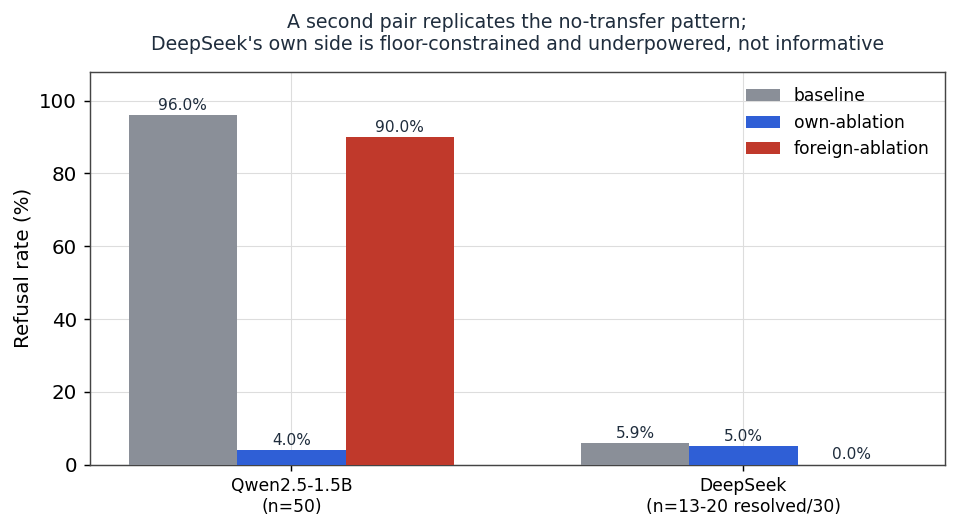

In [9]:
groups = ["Qwen2.5-1.5B\n(n=50)", "DeepSeek\n(n=13-20 resolved/30)"]
conds = ["baseline", "own_ablation", "foreign_ablation"]
cond_labels = ["baseline", "own-ablation", "foreign-ablation"]
cond_colors = [PALETTE["gray"], PALETTE["blue"], PALETTE["vermilion"]]
data = {groups[0]: qwen25_stats, groups[1]: deepseek_stats}

x = range(len(groups))
width = 0.24
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for j, cond in enumerate(conds):
    vals = [data[g][cond]["rate"] * 100 for g in groups]
    offset = (j - 1) * width
    bars = ax.bar([i + offset for i in x], vals, width=width, color=cond_colors[j], label=cond_labels[j], zorder=3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=8.5, color=PALETTE["ink"])
ax.set_ylim(0, 108)
ax.set_ylabel("Refusal rate (%)")
ax.set_xticks(list(x))
ax.set_xticklabels(groups, fontsize=9.5)
ax.set_title(
    "A second pair replicates the no-transfer pattern;\nDeepSeek's own side is floor-constrained and underpowered, not informative",
    color=PALETTE["ink"], pad=12, fontsize=10.5,
)
ax.legend(frameon=False, fontsize=9.5, loc="upper right")
plt.tight_layout()
plt.show()

**Qwen2.5-1.5B: a second clean no-transfer result, matching the first pair
exactly.** Own-ablation crashes refusal (96%->4%, p=0.0); DeepSeek's
foreign direction barely moves it (96%->90%, p=0.25, not significant) --
own-vs-foreign is clearly different (p=0.0).

**DeepSeek: genuinely underpowered, reported honestly as inconclusive
rather than overclaimed.** Baseline refusal on this 30-prompt sample is
already near floor (5.9%), and heavy truncation shrinks the McNemar
paired-n to single digits (6-10 prompts per comparison) -- all three
comparisons come back p=1.0, reflecting a test with almost no power to
detect anything, not evidence of no effect.

## Conclusions & Interpretation

**A refusal direction's causal power does not travel to a different
model, on either axis tested, across two independent architecture-matched
pairs.** Qwen3-8B and Qwen2.5-1.5B both give clean, unambiguous
no-transfer results under ablation; Qwen3-8B and Llama-3.1-8B both give a
clean no-transfer result under activation addition too. Four separate
no-transfer findings, two different pairs, two different intervention
types -- not one result generalized past what the data supports.

**One genuinely unresolved thread, stated plainly rather than smoothed
over.** Llama-3.1-8B's *own* dense-direction ablation effect (92%->88%) is
real in sign but not significant at n=50, and an independent n=75
replication found an even smaller gap -- this project's own data cannot
establish that Llama's dense direction is causally necessary for its
refusal, only that its causal contribution (if any) is small relative to
what a single SAE feature achieves in the same model (98%->10%, see
`mechanism.ipynb`). "Own vs. foreign not significant" for Llama is
therefore an underpowered comparison, not a second no-transfer result on
par with Qwen3-8B's or Qwen2.5-1.5B's.

**DeepSeek's side of the second pair is a null result in name only.**
Floor-constrained baseline and heavy truncation leave every comparison at
single-digit paired-n -- worth reporting as attempted and inconclusive,
not silently dropped or misread as a third confirmation.

**Caveat.** All four clean findings come from two model pairs (four models
total) at one parameter scale (1.5B-8B); this is evidence that causal
refusal directions are model-specific artifacts rather than a shared
linear feature transportable across architectures, not a proof that no
direction ever transfers between any two models -- see
`reports/RESULTS.md` for the full account, including what remains
genuinely open.